# Readme

Plot responses by type.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import skeliner as sk
from pywarper.warpers import get_z_profile
from eyewire2_functional_analysis.plot import plot_chirp, plot_bar_dir, plot_morph, plot_bar, plot_scale_bar

[Info] scikit-sparse not found. Falling back to scipy.sparse.linalg.spsolve.
[pywarper.surface] Optional dependency 'scikit-sparse' (CHOLMOD bindings) not found. Falling back to SciPy's sparse linear solver, which is ≈5–10× slower for large problems.

For platform-specific instructions see the project README:
	https://github.com/berenslab/pywarper#installation


In [2]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../data/preprocessed-data"
nuc_col_master='Updated Nuc ID (Sept 2)'
seg_col_master='Updated Seg ID (Sept 2)'

df_merged = data_loader.load_df_rois_morph(
    morph_folder="../../data/morphological-data",
    data_folder="../../data/preprocessed-data",
    nuc_col_master=nuc_col_master,
    seg_col_master=seg_col_master,
)

# Plot function

In [3]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):
    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

In [4]:
swc_dir = 'Y:/data/Eyewire2/morphologies-ew2/swc-norm/c6fb66deed2b53502e41fdcec0caa3b9'
swc_files = [f for f in os.listdir(swc_dir) if f.endswith('.swc')]

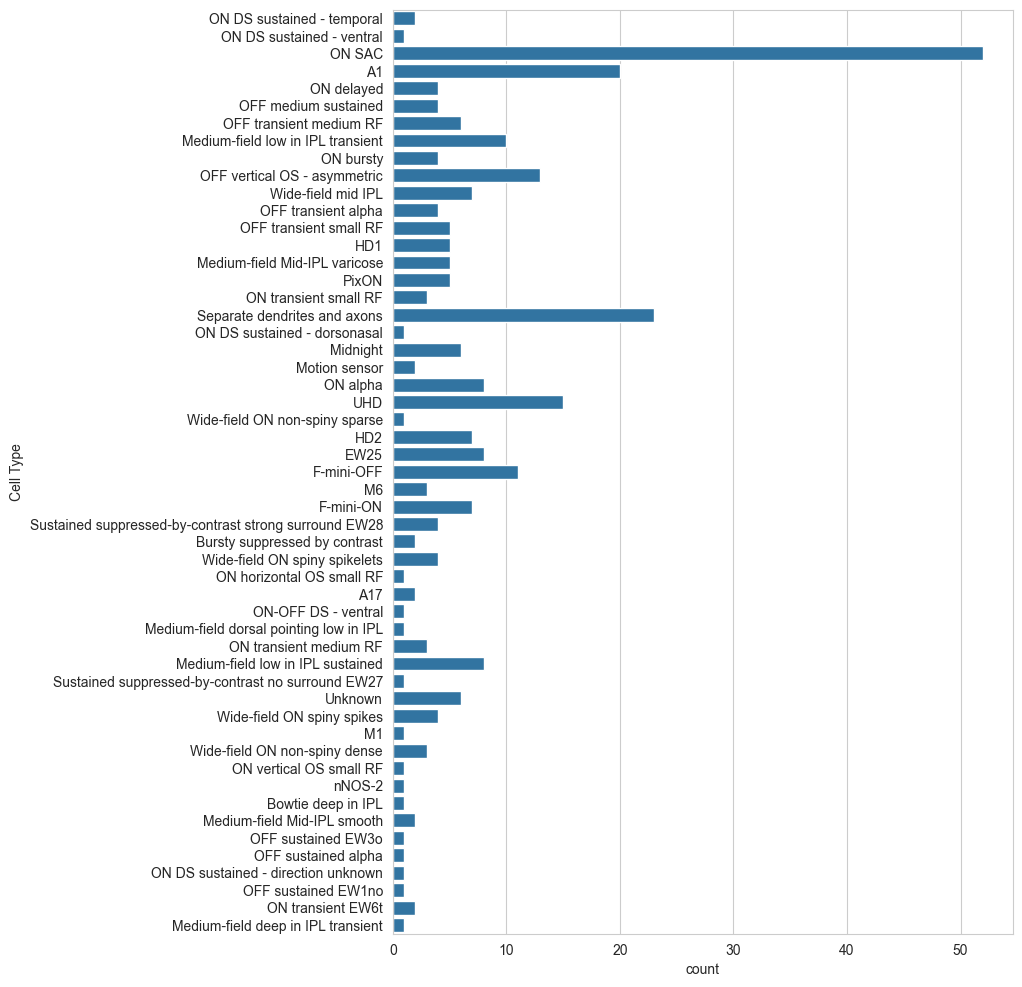

In [5]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

In [6]:
t_chirp = np.arange(df_merged.chirp_average_norm.iloc[0].size) * df_merged.chirp_average_dt.iloc[0]
t_bar = np.arange(df_merged.bar_time_component.iloc[0].size) * df_merged.bar_snippets_dt.iloc[0]

In [7]:
def plot_ipl_profile(ax, row):
    skel = row['skel']
    z_dict = get_z_profile(
        skel=skel,
        extent=[-30, 20],
    )
    ipl = z_dict['x']
    dens = z_dict['distribution']

    vmax = dens.max()

    ax.set_aspect('auto', 'box')
    ax.set_ylim(-30, 20)

    ax.plot([-0.1*vmax, vmax*1.1], [0, 0], c='darkblue', ls='--', lw=1.5)
    ax.text(1.1*vmax, 0, 'ON', va='center', ha='left', color='darkblue', fontsize=8)
    ax.plot([-0.1*vmax, vmax*1.1], [12, 12], c='darkgreen', ls='--', lw=1.5)
    ax.text(1.1*vmax, 12, 'OFF', va='center', ha='left', color='darkgreen', fontsize=8)

    ax.set_xlim(-0.1*vmax, vmax*1.1)
    ax.plot(dens, ipl, c='darkred', lw=2)
    #ax.set_title('xz', loc='left', y=0.9, va='top', fontsize=20)
    ax.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
    ax.axis('off')

In [20]:
def add_skels(df):
    df = df.copy()

    df['swc_path'] = df[seg_col_master].apply(lambda x: os.path.join(swc_dir, f"{x}.swc"))
    df['swc_exists'] = df['swc_path'].apply(lambda x: os.path.isfile(x))
    if np.any(~df['swc_exists']):
        print('SWC not found:', df[~df['swc_exists']].swc_path)
    df = df[df['swc_exists']]
    df['skel'] = df['swc_path'].apply(lambda x: sk.io.load_swc(x))
    return df

def plot_cells(df):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    fig, axs = plt.subplots(len(df), 6, figsize=(7, len(df) * 0.9), width_ratios=(0.8, 0.8, 0.5, 1.6, 1.6, 0.6))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    for i, (seg_id, row) in enumerate(df.iterrows()):
        ax = axs[i, 2]
        plot_ipl_profile(ax=ax, row=row)

        ax = axs[i, 1]
        rad = 200
        sx, sy, sz = plot_morph(ax=ax, row=row, rad=rad)
        ax.set_rasterized(True)

        ax = axs[i, 0]
        rad = 180
        ax.set_xlim(sx - rad, sx + rad)
        ax.set_ylim(sy + rad, sy - rad)
        plot_scale_bar(ax=ax, x0=sx, y0=sy, size=100, text=True, unit='µm', tdist=-0.1*rad, fontsize=12)

        ax = axs[i, 3]
        plot_chirp(ax=ax, row=row)
        if i == (df.shape[0] - 1):
            plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.1, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 4]
        plot_bar(ax=ax, row=row, annotate_dirs=False, annotate_symbols=i==0)
        if i == (df.shape[0] - 1):
            plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.1, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 5]
        plot_bar_dir(ax=ax, row=row)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')
        ax.set_facecolor((1, 1, 1, 0))

    plt.tight_layout(h_pad=0.4, w_pad=0)
    return fig, axs

In [21]:
fig_dir = './figures/examples'
os.makedirs(fig_dir, exist_ok=True)

In [22]:
#list(df_merged.columns)

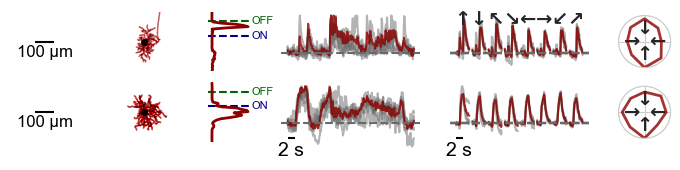

In [23]:
# For Sebastian
df_type = df_merged[
    (df_merged['roi_id'].astype(int).isin([62, 52]))
    & (df_merged["field"] == 'GCL2')
]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

fig, axs = plot_cells(df_type)
#plt.savefig(os.path.join(fig_dir, 'examples_GCL2_52_62.svg'), transparent=True, dpi=600)
plt.show()

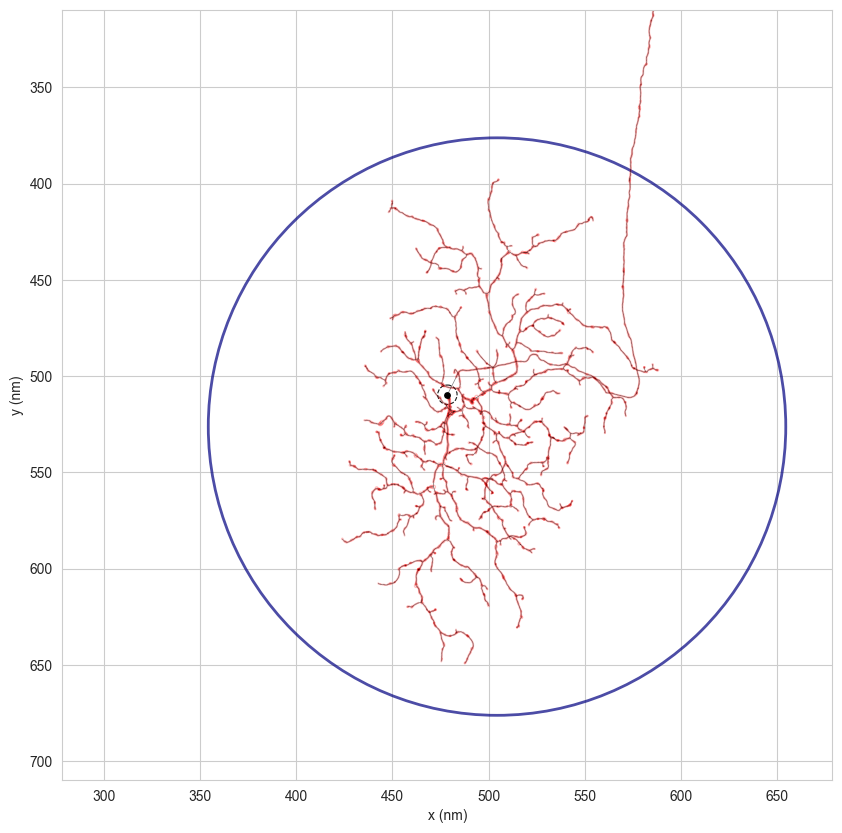

In [24]:
row = add_skels(df_type).iloc[0]

dorsal_offset = row['ventral_dorsal_pos_um'] - row['field_ventral_dorsal_pos_um']
nasal_offset = row['temporal_nasal_pos_um'] - row['field_temporal_nasal_pos_um']

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sx, sy, sz = plot_morph(ax=ax, row=row, rad=200)


import matplotlib.patches as patches


circle = patches.Circle((sx-nasal_offset, sy-dorsal_offset), radius=150,
                       facecolor='none',
                       edgecolor='navy',
                       linewidth=2,
                       alpha=0.7)
ax.add_patch(circle)


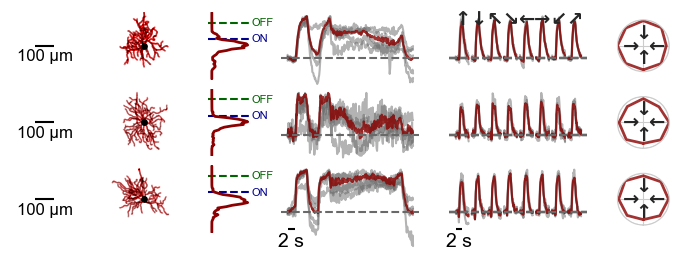

In [25]:
son_alpha_list = [720575940557469707, 720575940562911131, 720575940572157287, 720575940575066105]

df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(son_alpha_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
]

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])

plt.savefig(os.path.join(fig_dir, 'examples_son_alphas.svg'), transparent=True, dpi=600)

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


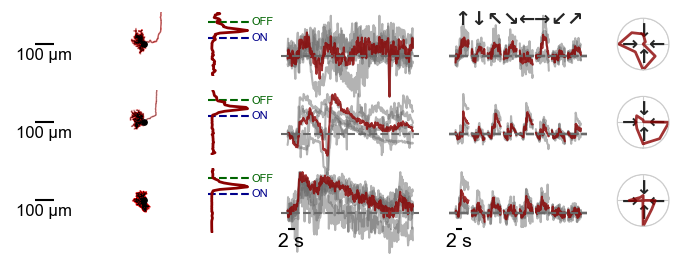

In [26]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

# fig, axs = plot_cells(df_type)
# plt.savefig(os.path.join(fig_dir, 'examples_all_uhd.svg'), transparent=True, dpi=600)
# plt.show()

fig, axs = plot_cells(df_type.iloc[[2, 4, -1]])
plt.savefig(os.path.join(fig_dir, 'examples_uhd.svg'), transparent=True, dpi=600, bbox_inches='tight')
plt.show()

# fig, ax = plot_mosaic(add_skels(df_type), extent = (330, 980, 0, 650))
# plt.savefig(os.path.join(fig_dir, 'mosaic_uhd.pdf'))
# plt.show()

[720575940563567973 720575940576092590 720575940581355463
 720575940563588453]


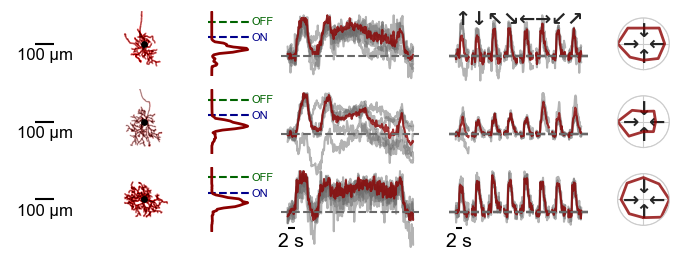

In [27]:
pixon_list = [720575940563567973, 720575940563588453, 720575940576092590, 720575940581355463]

df_type = df_merged[
    ((df_merged['Cell Type'] == 'PixON') | (
            (df_merged['Machine label'] == '9n') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    #(df_merged[seg_col_master].astype(int).isin(pixon_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
plt.savefig(os.path.join(fig_dir, 'examples_pixon.svg'), transparent=True, dpi=600, bbox_inches='tight')